In [ ]:
import os
import tensorflow as tf
from tensorflow import keras
print("TensorFlow Version: ", tf.__version__)

TensorFlow Version:  2.20.0


##Dataset Configuration
Define the paths to the training, validation, and test datasets stored in Google Drive. Keeping these paths centralized makes the notebook easier to maintain and update if the dataset location changes.

In [ ]:
DATASET_PATH = "/content/drive/MyDrive/Hybrid-Colon-Cancer-Detection/data/processed"
TRAIN_DIR = os.path.join(DATASET_PATH, "train")
VALIDATION_DIR = os.path.join(DATASET_PATH, "validation")
TEST_DIR = os.path.join(DATASET_PATH, "test")
print("Dataset path     :", DATASET_PATH)
print("Train path       :", TRAIN_DIR)
print("Validation path  :", VALIDATION_DIR)
print("Test path        :", TEST_DIR)

Dataset path     : /content/drive/MyDrive/Hybrid-Colon-Cancer-Detection/data/processed
Train path       : /content/drive/MyDrive/Hybrid-Colon-Cancer-Detection/data/processed/train
Validation path  : /content/drive/MyDrive/Hybrid-Colon-Cancer-Detection/data/processed/validation
Test path        : /content/drive/MyDrive/Hybrid-Colon-Cancer-Detection/data/processed/test


## Verify Dataset
Verify that the dataset directories exist and are accessible before training. This helps detect incorrect paths or missing files early in the workflow.

In [ ]:
print("Dataset exists     :", os.path.exists(DATASET_PATH))
print("Train exists       :", os.path.exists(TRAIN_DIR))
print("Validation exists  :", os.path.exists(VALIDATION_DIR))
print("Test exists        :", os.path.exists(TEST_DIR))

Dataset exists     : True
Train exists       : True
Validation exists  : True
Test exists        : True


##Image Configuration
Define the image size, batch size, and random seed used throughout the training pipeline. Centralizing these parameters improves consistency,reproducibility, and maintainability.

In [ ]:
IMAGE_SIZE = (224,224)
BATCH_SIZE = 32
SEED = 42

## Create TensorFlow Datasets
Load the training, validation, and test datasets using TensorFlow's `image_dataset_from_directory()`. Images are automatically loaded, resized, batched, and labeled based on their parent directory.

In [ ]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size = IMAGE_SIZE,
    batch_size = BATCH_SIZE,
    seed = SEED
)
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    VALIDATION_DIR,
    image_size = IMAGE_SIZE,
    batch_size = BATCH_SIZE,
    seed = SEED
)
test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size = IMAGE_SIZE,
    batch_size = BATCH_SIZE,
    seed = SEED
)

Found 8008 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.


## Inspect Dataset
Inspect the loaded datasets to verify that images, labels, and batch dimensions are correct before training the model.

In [ ]:
print("Class Names:", train_dataset.class_names)
for images, labels in train_dataset.take(1):
    print("Batch Shape :", images.shape)
    print("Lable Batch Shape :", labels.shape)

Class Names: ['colon_aca', 'colon_n']
Batch Shape : (32, 224, 224, 3)
Lable Batch Shape : (32,)


## Visualize Sample Images
Display a batch of training images along with their corresponding class labels to verify that the dataset has been loaded correctly.

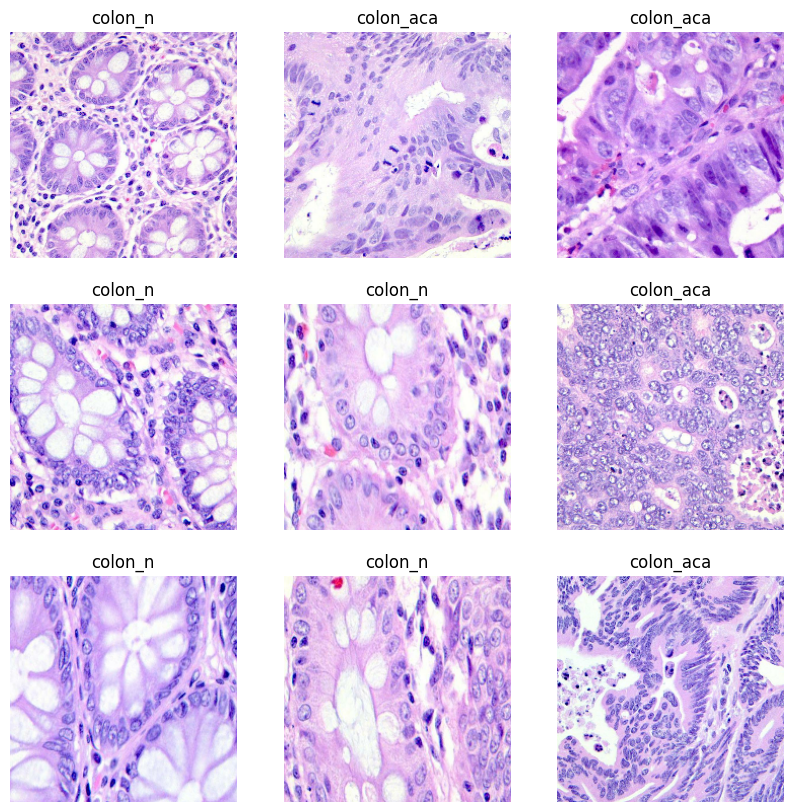

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
for images, labels in train_dataset.take(1):
  for i in range(9):
    ax = plt.subplot(3,3,i+1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(train_dataset.class_names[labels[i]])
    plt.axis("off")

## Data Augmentation
Apply random image transformations during training to improve model generalization and reduce overfitting. These transformations are applied dynamically without modifying the original dataset.

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
 ])

## Visualize Data Augmentation
Display augmented versions of a training image to verify that random transformations are applied correctly during training.

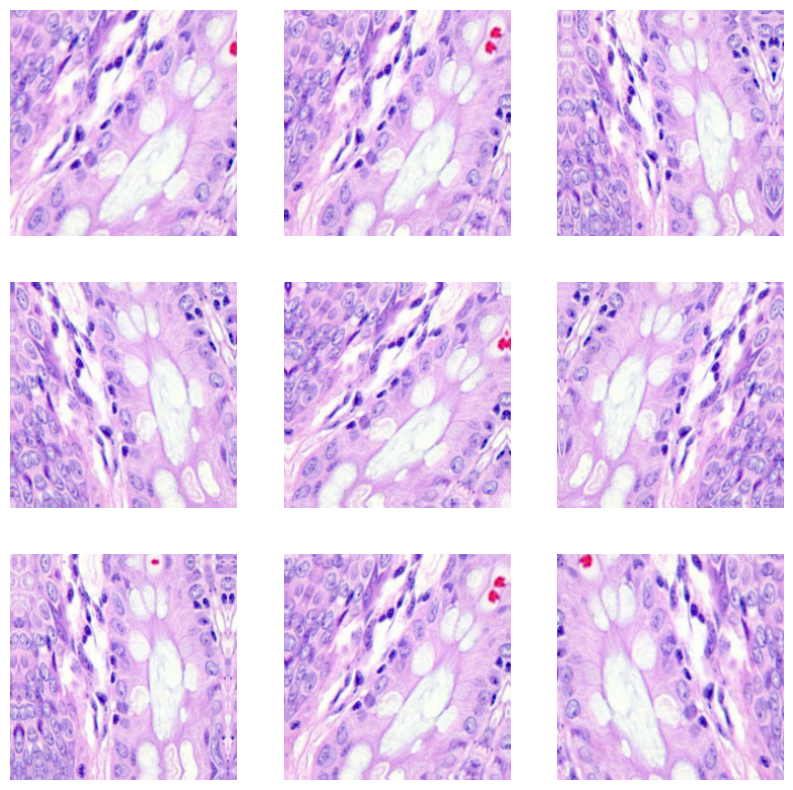

In [ ]:
plt.figure(figsize=(10,10))
for images, _ in train_dataset.take(1):
  first_image = images[0]
  for i in range(9):
    plt.subplot(3,3,i+1)
    augmented_image = data_augmentation(tf.expand_dims(first_image,axis=0))
    plt.imshow(augmented_image[0].numpy().astype("uint8"))
    plt.axis("off")
plt.show()

## Optimize Dataset Pipeline
Optimize the input pipeline to improve training performance by allowing data preparation and model execution to overlap.

In [ ]:
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)
validation_dataset = validation_dataset.prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)

## Import Required Libraries
Import the libraries required to build the ResNet50 transfer learning model for colon cancer classification.

In [1]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import(
    GlobalAveragePooling2D,
    Dense,
    Dropout
)
from tensorflow.keras.models import Model


## Load the Pretrained ResNet50 Model
Load the pretrained ResNet50 model with ImageNet weights and exclude the original classification layer to use it as a feature extractor.

In [2]:
base_model = ResNet50(
    weights = "imagenet",
    include_top = False,
    input_shape = (224,224,3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


## Freeze the Base Model
Freeze the pretrained ResNet50 base model to preserve its learned feature extraction capabilities during the initial training phase. Only the newly added classification layers will be trained.

In [3]:
base_model.trainable = False

## Build the Custom Classification Head
Build a custom classification head on top of the pretrained ResNet50 feature extractor. The new layers are responsible for learning the colon cancer classification task.

In [4]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation = 'relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(2, activation = 'softmax')(x)
model = Model(inputs = base_model.input, outputs = predictions)

## Compile the Model
Compile the hybrid model by specifying the optimizer, loss function, and evaluation metric. This prepares the model for the training process.

In [5]:
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

## Display the Model Summary
Display the architecture of the hybrid model, including the pretrained ResNet50 base model and the newly added classification layers.

In [6]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,112,770 (91.98 MB)

 Trainable params: 525,058 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)